# Práctica Computacional: Teoría de Sturm-Liouville
## Física Matemática I — Wolfram Language 12.3

Este cuaderno pone en práctica, de manera computacional, la **Teoría de Sturm-Liouville** vista en clase (15 de abril de 2026). Se realizarán:
- Cálculos simbólicos para verificar las propiedades algebraicas de los operadores.
- Representaciones visuales de las autofunciones (polinomios de Legendre, funciones de Bessel, polinomios de Hermite).
- Verificaciones numéricas de ortogonalidad, normalización y hermiticidad.

Los temas cubiertos son:
1. **El Operador de Sturm-Liouville**: forma general, operador adjunto y condición de autoadjunción.
2. **Ejemplo 1 – Polinomios de Legendre**: verificación simbólica, fórmula de Rodrigues, ortogonalidad y series.
3. **Ejemplo 2 – Funciones de Bessel**: factor integrante, gráficas, ceros y ortogonalidad.
4. **Ecuación de Hermite y Oscilador Armónico Cuántico**: funciones de onda, niveles de energía y densidades de probabilidad.
5. **Demostración numérica de la hermiticidad**: verificación de $(\mathscr{L}f, g) = (f, \mathscr{L}g)$ y realidad de autovalores.

## Inicialización

In [2]:
(* Limpiar definiciones previas y configurar el entorno *)
Clear["Global`*"];
$MaxExtraPrecision = 50;

(* Paleta de colores consistente para las gráficas *)
colores = {RGBColor[0.12, 0.47, 0.71], RGBColor[1, 0.50, 0.05],
           RGBColor[0.17, 0.63, 0.17], RGBColor[0.84, 0.15, 0.16],
           RGBColor[0.58, 0.40, 0.74], RGBColor[0.55, 0.34, 0.29]};

Print["Entorno inicializado. Wolfram Language ", $VersionNumber]

Entorno inicializado. Wolfram Language 12.3


---
# 1. El Operador de Sturm-Liouville: Cálculo Simbólico

## 1.1 Definición del Operador y su Adjunto

Consideramos el operador diferencial de segundo orden:
$$\mathscr{L} f = a_2(x) f''(x) + a_1(x) f'(x) + a_0(x) f(x)$$

Para coeficientes reales, el **operador adjunto** es:
$$\overline{\mathscr{L}}\, g = \frac{d^2}{dx^2}[a_2(x)\, g(x)] - \frac{d}{dx}[a_1(x)\, g(x)] + a_0(x)\, g(x)$$

Expandiendo $\overline{\mathscr{L}}$ con la regla del producto se obtiene:
$$\overline{\mathscr{L}}\, g = a_2 g'' + (2a_2' - a_1) g' + (a_2'' - a_1' + a_0) g$$

El operador es **autoadjunto** ($\mathscr{L} = \overline{\mathscr{L}}$) si y sólo si $a_1(x) = a_2'(x)$.

In [174]:
(* --- Definición simbólica del operador L y su adjunto --- *)
(* Declarar a2, a1, a0 como funciones simbólicas de x *)
a2 /: Derivative[n_][a2][x_] := Derivative[n][a2][x];  (* mantener simbólico *)

(* Operador L aplicado a una función f *)
Lop[f_, x_] := a2[x] D[f[x], {x, 2}] + a1[x] D[f[x], x] + a0[x] f[x]

(* Operador adjunto L† (para coeficientes reales) *)
Ladjop[g_, x_] := D[a2[x] g[x], {x, 2}] - D[a1[x] g[x], x] + a0[x] g[x]

(* Expandir el operador adjunto explícitamente *)
(* Aplicamos a una función genérica g[x] *)
adjExpanded = Ladjop[g, x] // Expand
Print["Operador adjunto expandido:"]
Print["L†[g] = ", adjExpanded]

TagSetDelayed::tagpos:             (n_)
Tag a2 in a2    [x_] is too deep for an assigned rule to be found.

Operador adjunto expandido:
L\[Dagger][g] = a0[x] g[x] - g[x] a1'[x] - a1[x] g'[x] + 2 a2'[x] g'[x] + 
 
>    g[x] a2''[x] + a2[x] g''[x]


a0[x] g[x] - g[x] a1'[x] - a1[x] g'[x] + 2 a2'[x] g'[x] + g[x] a2''[x] + a2[x] g''[x]

In [186]:
(* --- Condición de autoadjunción --- *)
(* L = L† si y sólo si el coeficiente de g' es igual en ambos operadores *)
(* En L:  coeficiente de g' es a1[x] *)
(* En L†: coeficiente de g' es 2*a2'[x] - a1[x] *)
(* Igualando: a1[x] = 2*a2'[x] - a1[x]  =>  2*a1[x] = 2*a2'[x]  =>  a1[x] = a2'[x] *)

Print["Condición de autoadjunción: a1(x) = d/dx[a2(x)]"]
Print[""]
Print["Verificación algebraica (debe ser 0 si L = L†):"]
diferencia = Ladjop[g, x] - Lop[g, x] // Expand
Print["L†[g] - L[g] = ", diferencia]
Print[""]
Print["Factorizando el resultado:"]
Print["L†[g] - L[g] = (2 a2' - 2 a1) g' + (a2'' - a1') g"]
Print["Si a1 = a2', entonces: L†[g] - L[g] = 0  ✓"]

Condicio'n de autoadjuncio'n: a1(x) = d/dx[a2(x)]

Verificacio'n algebraica (debe ser 0 si L = L\[Dagger]):
L\[Dagger][g] - L[g] = -(g[x] a1'[x]) - 2 a1[x] g'[x] + 2 a2'[x] g'[x] + 
 
>    g[x] a2''[x]

Factorizando el resultado:
L\[Dagger][g] - L[g] = (2 a2' - 2 a1) g' + (a2'' - a1') g
Si a1 = a2', entonces: L\[Dagger][g] - L[g] = 0  \[Checkmark]


-(g[x] a1'[x]) - 2 a1[x] g'[x] + 2 a2'[x] g'[x] + g[x] a2''[x]

In [200]:
(* --- Factor integrante para convertir L en forma autoadjunta --- *)
(* Si a1 ≠ a2', se multiplica la ecuación por el factor integrante: *)
(*   p(x) = (1/a2) * Exp[ Integral(a1/a2, dx) ] *)

Print["Factor integrante p(x) para la forma autoadjunta:"]
Print["p(x) = (1/a2) * Exp[ ∫ (a1/a2) dx ]"]
Print[""]
Print["Al multiplicar L[f] = 0 por p(x), el operador se convierte en:"]
Print["d/dx[ p(x)*a2(x) * f'(x) ] + p(x)*a0(x)*f(x) = 0"]
Print[""]
Print["En esta forma:"]
Print["  - Función de peso: ρ(x) = p(x)"]
Print["  - p(x)*a2(x) = Exp[∫ a1/a2 dx]  actúa como p(x) en la forma SL"]

Factor integrante p(x) para la forma autoadjunta:
p(x) = (1/a2) * Exp[ \[Integral] (a1/a2) dx ]

Al multiplicar L[f] = 0 por p(x), el operador se convierte en:
d/dx[ p(x)*a2(x) * f'(x) ] + p(x)*a0(x)*f(x) = 0

En esta forma:
  - Funcio'n de peso: \[Rho](x) = p(x)
  - p(x)*a2(x) = Exp[\[Integral] a1/a2 dx]  actu'a como p(x) en la forma SL


---
# 2. Ejemplo 1: Polinomios de Legendre

## 2.1 La Ecuación Diferencial de Legendre

$$(1-x^2)f''(x) - 2x f'(x) + l(l+1)f(x) = 0$$

Identificamos los coeficientes:
- $a_2(x) = 1 - x^2$
- $a_1(x) = -2x$  
- $a_0(x) = l(l+1)$

**Verificación de autoadjunción:** $\dfrac{d}{dx}(1-x^2) = -2x = a_1(x)$ ✓

La forma compacta de Sturm-Liouville es:
$$\frac{d}{dx}\left[(1-x^2)\frac{df}{dx}\right] + l(l+1)f = 0$$
con $p(x)=1-x^2$, $q(x)=0$, $\rho(x)=1$ y $\lambda = l(l+1)$.

In [334]:
(* --- Verificación simbólica de autoadjunción del operador de Legendre --- *)
a2Leg[x_] := 1 - x^2
a1Leg[x_] := -2 x
a0Leg[x_] := l (l + 1)

(* Condición: a1 = d/dx[a2] *)
derivA2 = D[a2Leg[x], x]
Print["d/dx(1 - x²) = ", derivA2]
Print["a1(x) = ", a1Leg[x]]
Print["¿ a1 = a2' ? ", FullSimplify[derivA2 == a1Leg[x]]]
Print[""]

(* Escribir la forma SL compacta *)
Print["Forma de Sturm-Liouville:"]
Print["d/dx[(1-x²) df/dx] + l(l+1) f = 0"]
Print[""]

(* Verificar expandiendo la forma SL *)
SLform[f_, x_] := D[(1 - x^2) D[f[x], x], x] + l (l + 1) f[x]
LegendreForm[f_, x_] := (1 - x^2) D[f[x], {x, 2}] - 2 x D[f[x], x] + l (l + 1) f[x]
Print["¿ Forma SL ≡ Ecuación de Legendre? ", FullSimplify[SLform[f, x] == LegendreForm[f, x]]]

d/dx(1 - x\262) = -2 x
a1(x) = -2 x
\[DownQuestion] a1 = a2' ? True

Forma de Sturm-Liouville:
d/dx[(1-x\262) df/dx] + l(l+1) f = 0

\[DownQuestion] Forma SL \[Congruent] Ecuacio'n de Legendre? True


-2 x

## 2.2 Fórmula de Rodrigues

Los polinomios de Legendre $P_l(x)$ pueden generarse mediante la **fórmula de Rodrigues**:

$$P_l(x) = \frac{1}{2^l \, l!} \frac{d^l}{dx^l}(x^2 - 1)^l$$

Esta fórmula garantiza que $P_l(x)$ sea un polinomio de grado $l$ con coeficiente líder positivo.

Polinomios de Legendre vi'a Rodrigues:


l   Rodrigues P_l(x)                   LegendreP[l,x]                     ¿Coincide?
   0   1                                  1                                  True

   1   x                                  x                                  True

                 2                                  2
         1    3 x                           1    3 x
       -(-) + ----                        -(-) + ----
   2     2     2                            2     2                          True

                 3                                  3
       -3 x   5 x                         -3 x   5 x
       ---- + ----                        ---- + ----
   3    2      2                           2      2                          True

               2       4                          2       4
       3   15 x    35 x                   3   15 x    35 x
       - - ----- + -----                  - - ----- + -----
   4   8     4       8                    8     4       8                    True

                  3       5                          3       5
       15 x   35 x    63 x                15 x   35 x    63 x
       ---- - ----- + -----               ---- - ----- + -----
   5    8       4       8                  8       4       8                 True

                    2        4        6                2        4        6
         5     105 x    315 x    231 x      5     105 x    315 x    231 x
       -(--) + ------ - ------ + ------   -(--) + ------ - ------ + ------
   6     16      16       16       16       16      16       16       16     True
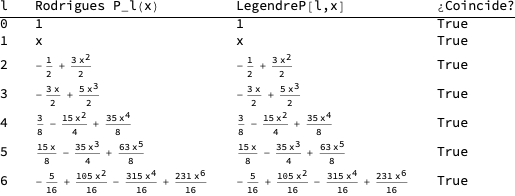

In [352]:
(* --- Fórmula de Rodrigues para polinomios de Legendre --- *)
rodriguesLeg[l_, x_] := 1/(2^l Factorial[l]) D[(x^2 - 1)^l, {x, l}]

(* Calcular los primeros 7 polinomios *)
Print["Polinomios de Legendre vía Rodrigues:"]
TableForm[
  Table[{l, rodriguesLeg[l, x] // Expand, LegendreP[l, x] // Expand,
         FullSimplify[rodriguesLeg[l, x] - LegendreP[l, x]] == 0},
        {l, 0, 6}],
  TableHeadings -> {None, {"l", "Rodrigues P_l(x)", "LegendreP[l,x]", "¿Coincide?"}}
]

Verificacio'n: cada P_l(x) satisface (1-x\262)P''- 2xP' + l(l+1)P = 0



l   Residual (debe ser 0)
   0   0

   1   0

   2   0

   3   0

   4   0

   5   0
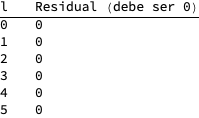

In [357]:
(* --- Verificar que P_l satisface la ecuación de Legendre --- *)
Print["Verificación: cada P_l(x) satisface (1-x²)P''- 2xP' + l(l+1)P = 0"]
Print[""]
Table[
  residual = (1 - x^2) D[LegendreP[n, x], {x, 2}] - 2 x D[LegendreP[n, x], x] + n (n + 1) LegendreP[n, x];
  {n, FullSimplify[residual]},
  {n, 0, 5}
] // TableForm[#, TableHeadings -> {None, {"l", "Residual (debe ser 0)"}}]&

## 2.3 Gráfica de los Polinomios de Legendre

Los polinomios de Legendre están definidos en el intervalo $[-1, 1]$ y satisfacen $P_l(1) = 1$ y $P_l(-1) = (-1)^l$.

Legended[-Graphics-, Placed[LineLegend[{Directive[FontSize -> 12, Opacity[1.], 
 
>       AbsoluteThickness[1.6], RGBColor[0.55, 0.34, 0.29]]}, 
 
>     {P_0(x), P_1(x), P_2(x), P_3(x), P_4(x), P_5(x)}, LegendMarkers -> None, 
 
>     LabelStyle -> {}, LegendLayout -> Column], After, Identity]]
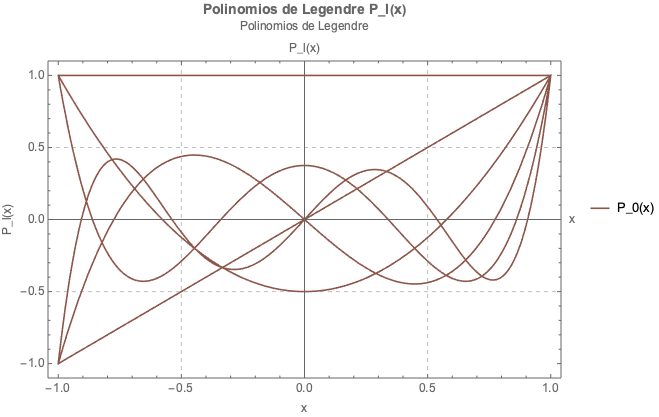

In [361]:
(* --- Gráfica de P_l(x) para l = 0, 1, 2, 3, 4, 5 --- *)
nMax = 5;
legendraPlot = Plot[
  Table[LegendreP[l, x], {l, 0, nMax}],
  {x, -1, 1},
  PlotStyle -> colores,
  PlotLegends -> Table["P_" <> ToString[l] <> "(x)", {l, 0, nMax}],
  PlotLabel -> Style["Polinomios de Legendre P_l(x)", 14, Bold],
  AxesLabel -> {"x", "P_l(x)"},
  GridLines -> Automatic,
  GridLinesStyle -> Directive[Gray, Dashed, Opacity[0.5]],
  ImageSize -> Large,
  PlotRange -> {-1.1, 1.1},
  Frame -> True,
  FrameLabel -> {{"P_l(x)", None}, {"x", "Polinomios de Legendre"}},
  BaseStyle -> {FontSize -> 12}
]

Valores en x = 1:  P_l(1) = 1 para todo l

Valores en x = -1: P_l(-1) = (-1)^l


l   P_l(1)
   0   1

   1   1

   2   1

   3   1

   4   1

   5   1
   l   P_l(-1)   (-1)^l
   0   1         1

   1   -1        -1

   2   1         1

   3   -1        -1

   4   1         1

   5   -1        -1
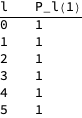
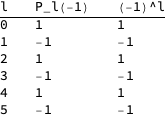

In [364]:
(* --- Propiedades en los extremos del intervalo --- *)
Print["Valores en x = 1:  P_l(1) = 1 para todo l"]
Table[{l, LegendreP[l, 1]}, {l, 0, 5}] // TableForm[#, TableHeadings -> {None, {"l", "P_l(1)"}}]&

Print[""]
Print["Valores en x = -1: P_l(-1) = (-1)^l"]
Table[{l, LegendreP[l, -1], (-1)^l}, {l, 0, 5}] // 
  TableForm[#, TableHeadings -> {None, {"l", "P_l(-1)", "(-1)^l"}}]&

## 2.4 Ortogonalidad de los Polinomios de Legendre

La propiedad fundamental de ortogonalidad establece:
$$\int_{-1}^{1} P_l(x) \, P_k(x) \, dx = \frac{2}{2l+1} \, \delta_{lk}$$

Esto significa que la **matriz de Gram** $G_{lk} = \int_{-1}^{1} P_l P_k \, dx$ es diagonal.

Matriz de ortogonalidad G[l,k] = Integral[-1,1] P_l(x)*P_k(x) dx
(Debe ser diagonal con entradas 2/(2l+1))



2    0    0    0    0    0

     2
     -
0    3    0    0    0    0

          2
          -
0    0    5    0    0    0

               2
               -
0    0    0    7    0    0

                    2
                    -
0    0    0    0    9    0

                         2
                         --
0    0    0    0    0    11
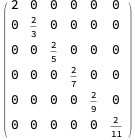

In [370]:
(* --- Verificación simbólica de ortogonalidad --- *)
nOrt = 5;
Print["Matriz de ortogonalidad G[l,k] = Integral[-1,1] P_l(x)*P_k(x) dx"]
Print["(Debe ser diagonal con entradas 2/(2l+1))"]
Print[""]

gramMatrix = Table[
  Integrate[LegendreP[l, x] LegendreP[k, x], {x, -1, 1}],
  {l, 0, nOrt}, {k, 0, nOrt}
];
gramMatrix // MatrixForm

\[DownQuestion] Matriz calculada = Fo'rmula anali'tica 2/(2l+1) \[Delta]_lk ?\
 
>   
True

Normas al cuadrado ||P_l||\262 = 2/(2l+1):


l   ||P_l||² calculada   2/(2l+1)
   0   2                    2

       2                    2
       -                    -
   1   3                    3

       2                    2
       -                    -
   2   5                    5

       2                    2
       -                    -
   3   7                    7

       2                    2
       -                    -
   4   9                    9

       2                    2
       --                   --
   5   11                   11
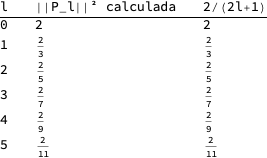

In [377]:
(* --- Comparar con la fórmula analítica 2/(2l+1)*delta_lk --- *)
analitica = Table[2/(2 l + 1) KroneckerDelta[l, k], {l, 0, nOrt}, {k, 0, nOrt}];
Print["¿ Matriz calculada = Fórmula analítica 2/(2l+1) δ_lk ? "]
Print[FullSimplify[gramMatrix == analitica]]
Print[""]
Print["Normas al cuadrado ||P_l||² = 2/(2l+1):"]
Table[{l, Integrate[LegendreP[l, x]^2, {x, -1, 1}], 2/(2 l + 1)}, {l, 0, 5}] //
  TableForm[#, TableHeadings -> {None, {"l", "||P_l||² calculada", "2/(2l+1)"}}]&

## 2.5 Series de Legendre (Expansión en Autofunciones)

Cualquier función $f(x)$ bien comportada en $[-1, 1]$ puede expandirse como:
$$f(x) = \sum_{l=0}^{\infty} c_l \, P_l(x), \quad \text{donde} \quad c_l = \frac{2l+1}{2} \int_{-1}^{1} f(x) \, P_l(x) \, dx$$

Esta es la **Serie de Legendre**, análoga a la serie de Fourier pero con los polinomios de Legendre como base ortogonal.

Coeficientes c_l de la expansio'n de f(x) = |x| en series de Legendre:


l   c_l (exacto)   c_l (numérico)
       1
       -
   0   2              0.500000

   1   0              0

       5
       -
   2   8              0.625000

   3   0              0

         3
       -(--)
   4     16           -0.187500

   5   0              0

       13
       ---
   6   128            0.101562

   7   0              0

         17
       -(---)
   8     256          -0.0664062
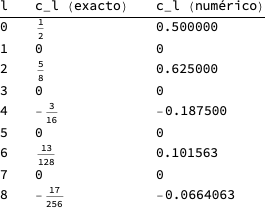

In [384]:
(* --- Serie de Legendre de una función --- *)
(* Usaremos f(x) = |x| como función de prueba *)
fFunc[x_] := Abs[x]

(* Calcular los coeficientes c_l *)
nTerms = 8;  (* número de términos en la serie *)
coefLeg[l_] := (2 l + 1)/2 Integrate[fFunc[x] LegendreP[l, x], {x, -1, 1}]

Print["Coeficientes c_l de la expansión de f(x) = |x| en series de Legendre:"]
coefs = Table[{l, coef = coefLeg[l], N[coef, 6]}, {l, 0, nTerms}];
coefs // TableForm[#, TableHeadings -> {None, {"l", "c_l (exacto)", "c_l (numérico)"}}]&

Legended[-Graphics-, Placed[LineLegend[{Directive[Opacity[1.], AbsoluteThickness[1.6], 
 
>       GrayLevel[0], Thickness[Large], Dashing[{Small, Small}]], 
 
>      Directive[Opacity[1.], AbsoluteThickness[1.6], RGBColor[0.12, 0.47, 0.71]], 
 
>      Directive[Opacity[1.], AbsoluteThickness[1.6], RGBColor[1, 0.5, 0.05]], 
 
>      Directive[Opacity[1.], AbsoluteThickness[1.6], RGBColor[0.17, 0.63, 0.17]], 
 
>      Directive[Opacity[1.], AbsoluteThickness[1.6], RGBColor[0.84, 0.15, 0.16]]}, 
 
>     {f(x) = |x|, Serie N=2, Serie N=4, Serie N=6, Serie N=8}, LegendMarkers -> None, 
 
>     LabelStyle -> {}, LegendLayout -> Column], After, Identity]]
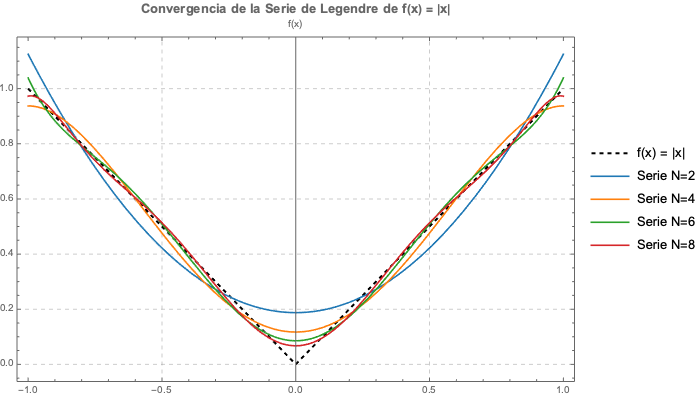

In [393]:
(* --- Gráfica de la convergencia de la serie de Legendre --- *)
(* Serie parcial con N términos *)
serieLeg[x_, nmax_] := Sum[coefLeg[l] LegendreP[l, x], {l, 0, nmax}]

Plot[
  Evaluate[Join[{fFunc[x]}, Table[serieLeg[x, n], {n, {2, 4, 6, 8}}]]],
  {x, -1, 1},
  PlotStyle -> Join[{Directive[Black, Thick, Dashed]}, 
                    {colores[[1]], colores[[2]], colores[[3]], colores[[4]]}],
  PlotLegends -> Join[{"f(x) = |x|"},
                      Table["Serie N=" <> ToString[n], {n, {2, 4, 6, 8}}]],
  PlotLabel -> Style["Convergencia de la Serie de Legendre de f(x) = |x|", 13, Bold],
  AxesLabel -> {"x", "f(x)"},
  ImageSize -> Large,
  Frame -> True,
  GridLines -> Automatic,
  GridLinesStyle -> Directive[Gray, Dashed, Opacity[0.4]]
]

Coeficientes c_l de f(x) = x\262:

Serie exacta: x\262 = (1/3)P_0(x) + (2/3)P_2(x)
Verificacio'n: (1/3)(1) + (2/3)((3x\262-1)/2) = 1/3 + x\262 - 1/3 = x\262 \
 
>   \[Checkmark]


l   c_l   Valor
       1     1
       -     -
   0   3     3

   1   0     0

       2     2
       -     -
   2   3     3

   3   0     0

   4   0     0
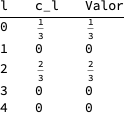

In [397]:
(* --- Serie de Legendre de otra función: f(x) = x^2 (exacta con pocos términos) --- *)
fFunc2[x_] := x^2
Print["Coeficientes c_l de f(x) = x²:"]
Table[{l, FullSimplify[coefLeg2 = (2 l + 1)/2 Integrate[fFunc2[x] LegendreP[l, x], {x, -1, 1}]],
       coefLeg2}, {l, 0, 4}] //
  TableForm[#, TableHeadings -> {None, {"l", "c_l", "Valor"}}]&

Print[""]
Print["Serie exacta: x² = (1/3)P_0(x) + (2/3)P_2(x)"]
Print["Verificación: (1/3)(1) + (2/3)((3x²-1)/2) = 1/3 + x² - 1/3 = x²  ✓"]

---
# 3. Ejemplo 2: Ecuación de Bessel y Funciones de Bessel

## 3.1 La Ecuación Diferencial de Bessel

$$x^2 y'' + x y' + (k^2 x^2 - \nu^2) y = 0$$

Identificamos $a_2(x) = x^2$, $a_1(x) = x$, $a_0(x) = -\nu^2/x^2 + k^2$ (tras dividir por $x^2$).

**¿Es autoadjunta?** $a_2'(x) = 2x \neq x = a_1(x)$. **No es autoadjunta.**

**Factor integrante:** $p(x) = \dfrac{1}{a_2} e^{\int a_1/a_2 \, dx} = \dfrac{1}{x^2} e^{\int 1/x \, dx} = \dfrac{1}{x^2} e^{\ln x} = \dfrac{1}{x}$

La **forma de Sturm-Liouville** resultante es:
$$\frac{d}{dx}\left[x\frac{dy}{dx}\right] + \left(k^2 x - \frac{\nu^2}{x}\right)y = 0$$
con $p(x) = x$, $q(x) = -\nu^2/x$, $\rho(x) = x$ y $\lambda = k^2$.

In [404]:
(* --- Derivación simbólica del factor integrante para Bessel --- *)
a2Bes[x_] := x^2
a1Bes[x_] := x

(* Verificar que NO es autoadjunto *)
Print["¿ a1(x) = d/dx[a2(x)] ?"]
Print["d/dx(x²) = ", D[a2Bes[x], x]]
Print["a1(x) = ", a1Bes[x]]
Print["¿ Son iguales? ", FullSimplify[D[a2Bes[x], x] == a1Bes[x]]]
Print["→ El operador NO es autoadjunto, necesita un factor integrante."]
Print[""]

(* Calcular el factor integrante *)
integral = Integrate[a1Bes[x]/a2Bes[x], x]
factorIntegrante = Exp[integral]/a2Bes[x] // Simplify
Print["Factor integrante p(x) = (1/a2) * Exp[∫ a1/a2 dx]:"]
Print["p(x) = ", factorIntegrante]
Print[""]

(* Verificar la forma SL resultante *)
pSL[x_] = x  (* p(x)*a2(x) = (1/x)*x^2 = x *)
Print["Forma SL: d/dx[x * dy/dx] + (k²x - ν²/x)y = 0"]
Print["Verificación de la forma SL expandida:"]
SLBessel[y_, x_] := D[x D[y[x], x], x] + (k^2 x - nu^2/x) y[x]
Bessel[y_, x_] := D[y[x], {x, 2}] + (1/x) D[y[x], x] + (k^2 - nu^2/x^2) y[x]
Print["¿ SL form ≡ Bessel/x ? ", FullSimplify[SLBessel[y, x] == x * Bessel[y, x]]]

\[DownQuestion] a1(x) = d/dx[a2(x)] ?
d/dx(x\262) = 2 x
a1(x) = x
\[DownQuestion] Son iguales? x == 0
-> El operador NO es autoadjunto, necesita un factor integrante.

Factor integrante p(x) = (1/a2) * Exp[\[Integral] a1/a2 dx]:
       1
p(x) = -
       x

Forma SL: d/dx[x * dy/dx] + (k\262x - \[Nu]\262/x)y = 0
Verificacio'n de la forma SL expandida:
\[DownQuestion] SL form \[Congruent] Bessel/x ? True


Log[x]
1
-
x
x

In [427]:
(* --- Verificar que J_ν(x) satisface la ecuación de Bessel --- *)
Print["Verificación simbólica: J_ν(x) satisface x²y'' + xy' + (x²-ν²)y = 0"]
Print["(con k=1 para simplificar)"]
Print[""]
Do[
  residual = x^2 D[BesselJ[nu, x], {x, 2}] + x D[BesselJ[nu, x], x] + (x^2 - nu^2) BesselJ[nu, x];
  resSimp = FullSimplify[residual];
  Print["ν = ", nu, ":  residual = ", resSimp],
  {nu, 0, 3}
]

Verificacio'n simbo'lica: J_\[Nu](x) satisface x\262y'' + xy' +\
 
>   (x\262-\[Nu]\262)y = 0
(con k=1 para simplificar)

\[Nu] = 0:  residual = 0
\[Nu] = 1:  residual = 0
\[Nu] = 2:  residual = 0
\[Nu] = 3:  residual = 0


## 3.2 Gráficas de las Funciones de Bessel

Las funciones de Bessel de primera clase $J_\nu(x)$ son la solución regular en el origen. Las de segunda clase $Y_\nu(x)$ divergen en $x=0$.

Legended[-Graphics-, Placed[LineLegend[{Directive[FontSize -> 12, Opacity[1.], 
 
>       AbsoluteThickness[1.6], RGBColor[0.84, 0.15, 0.16]]}, 
 
>     {J_0(x), J_1(x), J_2(x), J_3(x)}, LegendMarkers -> None, LabelStyle -> {}, 
 
>     LegendLayout -> Column], After, Identity]]
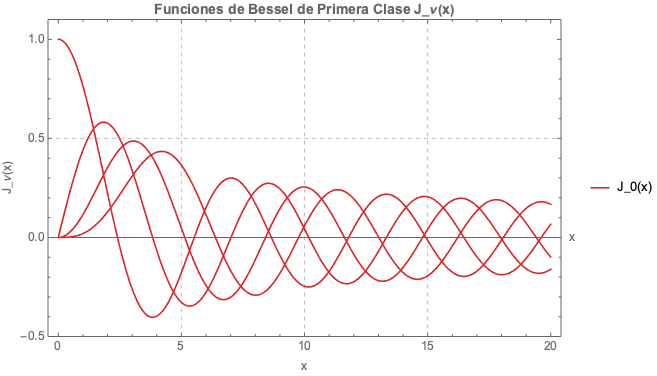

In [432]:
(* --- Gráfica de J_ν(x) para ν = 0, 1, 2, 3 --- *)
plotJbessel = Plot[
  Table[BesselJ[nu, x], {nu, 0, 3}],
  {x, 0, 20},
  PlotStyle -> colores[[1 ;; 4]],
  PlotLegends -> Table["J_" <> ToString[nu] <> "(x)", {nu, 0, 3}],
  PlotLabel -> Style["Funciones de Bessel de Primera Clase J_ν(x)", 14, Bold],
  AxesLabel -> {"x", "J_ν(x)"},
  GridLines -> Automatic,
  GridLinesStyle -> Directive[Gray, Dashed, Opacity[0.5]],
  ImageSize -> Large,
  PlotRange -> {-0.5, 1.1},
  Frame -> True,
  FrameLabel -> {{"J_ν(x)", None}, {"x", None}},
  BaseStyle -> {FontSize -> 12}
]

Legended[-Graphics-, Placed[LineLegend[{Directive[FontSize -> 12, Opacity[1.], 
 
>       AbsoluteThickness[1.6], RGBColor[0.84, 0.15, 0.16]]}, 
 
>     {Y_0(x), Y_1(x), Y_2(x), Y_3(x)}, LegendMarkers -> None, LabelStyle -> {}, 
 
>     LegendLayout -> Column], After, Identity]]
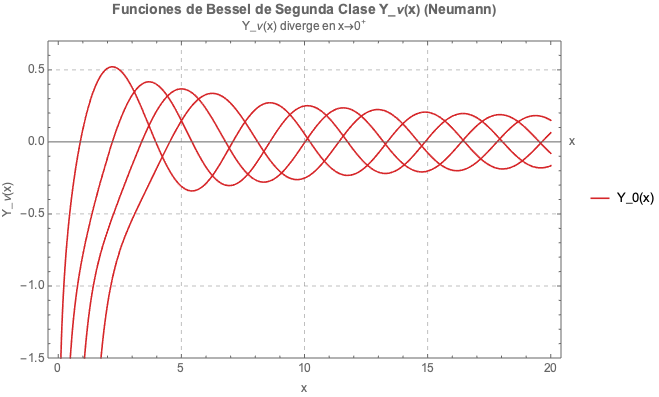

In [434]:
(* --- Gráfica de Y_ν(x) para ν = 0, 1, 2, 3 --- *)
plotYbessel = Plot[
  Table[BesselY[nu, x], {nu, 0, 3}],
  {x, 0.1, 20},
  PlotStyle -> colores[[1 ;; 4]],
  PlotLegends -> Table["Y_" <> ToString[nu] <> "(x)", {nu, 0, 3}],
  PlotLabel -> Style["Funciones de Bessel de Segunda Clase Y_ν(x) (Neumann)", 14, Bold],
  AxesLabel -> {"x", "Y_ν(x)"},
  GridLines -> Automatic,
  GridLinesStyle -> Directive[Gray, Dashed, Opacity[0.5]],
  ImageSize -> Large,
  PlotRange -> {-1.5, 0.7},
  Frame -> True,
  FrameLabel -> {{"Y_ν(x)", None}, {"x", "Y_ν(x) diverge en x→0⁺"}},
  BaseStyle -> {FontSize -> 12}
]

-Graphics-
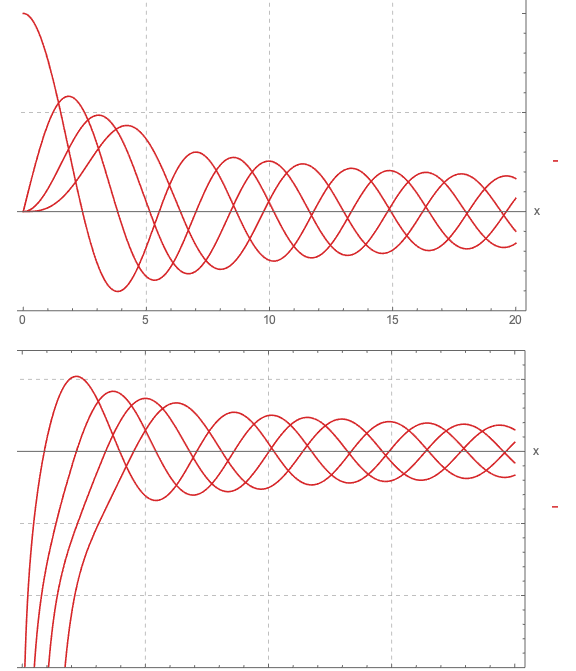

In [438]:
(* --- Gráfica combinada J e Y --- *)
GraphicsGrid[{{plotJbessel}, {plotYbessel}}, ImageSize -> Large]

## 3.3 Ceros de las Funciones de Bessel

Los ceros de $J_\nu(x)$, denotados $j_{\nu,k}$ (el $k$-ésimo cero de $J_\nu$), son fundamentales para problemas con condiciones de frontera. Son los autovalores del problema de Sturm-Liouville en el disco.

Ceros j_{\[Nu],k} de J_\[Nu](x) (primeros 5 ceros para \[Nu] = 0, 1, 2, 3):



ν = 0: {2.40623, 5.52009, 8.65373, 11.7915, 14.9309}
ν = 1: {3.83174, 7.01559, 10.1735, 13.3237, 16.4706}
ν = 2: {5.13564, 8.41725, 11.6198, 14.7960, 17.9598}
ν = 3: {6.38016, 9.76103, 13.0152, 16.2235, 19.4094}
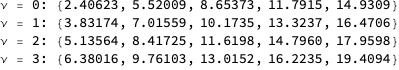

In [440]:
(* --- Ceros de J_ν(x) --- *)
Print["Ceros j_{ν,k} de J_ν(x) (primeros 5 ceros para ν = 0, 1, 2, 3):"]
Print[""]
cerosTable = Table[
  Row[{"ν = ", nu, ": ", 
       Table[N[BesselJZero[nu, k], 6], {k, 1, 5}]}],
  {nu, 0, 3}
];
Column[cerosTable]

Legended[-Graphics-, Placed[LineLegend[{Directive[Opacity[1.], AbsoluteThickness[1.6], 
 
>       RGBColor[0.12, 0.47, 0.71]], 
 
>      Directive[Opacity[1.], AbsoluteThickness[1.6], RGBColor[1, 0.5, 0.05]]}, 
 
>     {J_0(x), J_1(x)}, LegendMarkers -> None, LabelStyle -> {}, LegendLayout -> Column]\
 
>     , After, Identity]]
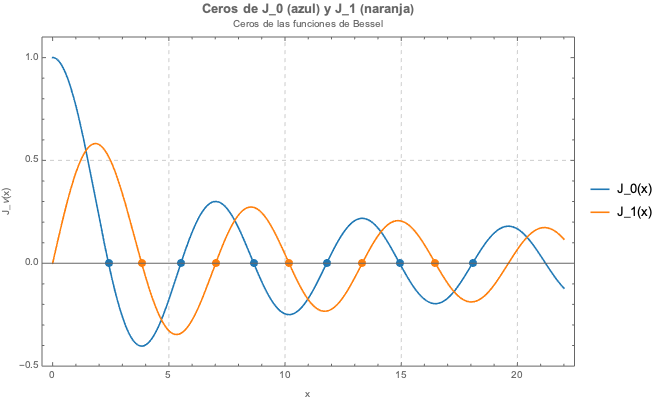

In [445]:
(* --- Visualizar los ceros sobre las curvas de Bessel --- *)
cerosJ0 = Table[{BesselJZero[0, k], 0}, {k, 1, 6}];
cerosJ1 = Table[{BesselJZero[1, k], 0}, {k, 1, 5}];

Show[
  Plot[
    {BesselJ[0, x], BesselJ[1, x]},
    {x, 0, 22},
    PlotStyle -> {colores[[1]], colores[[2]]},
    PlotLegends -> {"J_0(x)", "J_1(x)"},
    PlotRange -> {-0.5, 1.1},
    Frame -> True,
    GridLines -> Automatic,
    GridLinesStyle -> Directive[Gray, Dashed, Opacity[0.4]],
    FrameLabel -> {{"J_ν(x)", None}, {"x", "Ceros de las funciones de Bessel"}}
  ],
  ListPlot[cerosJ0, PlotStyle -> {Directive[colores[[1]], PointSize[0.015]]}],
  ListPlot[cerosJ1, PlotStyle -> {Directive[colores[[2]], PointSize[0.015]]}],
  ImageSize -> Large,
  PlotLabel -> Style["Ceros de J_0 (azul) y J_1 (naranja)", 13, Bold]
]

## 3.4 Ortogonalidad de las Funciones de Bessel

Dado que la forma SL tiene función de peso $\rho(x) = x$, las funciones $J_\nu(j_{\nu,k} x / a)$ son ortogonales en $[0, a]$:

$$\int_0^a x \, J_\nu\!\left(\frac{j_{\nu,k}}{a} x\right) J_\nu\!\left(\frac{j_{\nu,m}}{a} x\right) dx = \frac{a^2}{2} [J_{\nu+1}(j_{\nu,k})]^2 \, \delta_{km}$$

Ortogonalidad de J_0(j_{0,k} x) en [0,1] con peso \[Rho](x) = x:
Integral x J_0(j_{0,k} x) J_0(j_{0,m} x) dx para k,m = 1..4



NIntegrate::precw:                                                                    2
The precision of the argument function (x BesselJ[0, 2.404825558 x] ) is less than WorkingPrecision (15.).

NIntegrate::precw: The precision of the argument function (x BesselJ[0, 2.404825558 x] BesselJ[0, 5.520078110 x]) is less than WorkingPrecision (15.).

NIntegrate::slwcon: Numerical integration converging too slowly; suspect one of the following: singularity, value of the integration is 0, highly oscillatory integrand, or WorkingPrecision too small.

NIntegrate::ncvb:                                                                                                                                                                                                                                                                   -19                                                                          -19
NIntegrate failed to converge to prescribed accuracy after 9 recursive bisections in x near {x} = {0.99972057882518290045845402120149655839470238691454248399880218243}. NIntegrate obtained 9.7703321178795905814960269445684691549834481803767625033156537710 10    and 1.5511414962488334215816370349546795234091849644523301543876827199 10    for the integral and error estimates.

NIntegrate::precw: The precision of the argument function (x BesselJ[0, 2.404825558 x] BesselJ[0, 8.653727913 x]) is less than WorkingPrecision (15.).

General::stop: Further output of NIntegrate::precw will be suppressed during this calculation.

NIntegrate::ncvb:                                                                                                                                                                                                                                                                    -17                                                                          -18
NIntegrate failed to converge to prescribed accuracy after 9 recursive bisections in x near {x} = {0.86912508335946761959423454388148060498005815290146812851438629350}. NIntegrate obtained -1.4276079987125347446844153829105954951732052664446849539544345360 10    and 1.5912225589748293398332641046873502643084958323671516384600247916 10    for the integral and error estimates.

NIntegrate::ncvb:                                                                                                                                                                -16                        -17
NIntegrate failed to converge to prescribed accuracy after 9 recursive bisections in x near {x} = {0.720687583359468}. NIntegrate obtained -2.25777410636981 10    and 3.59204586644145 10    for the integral and error estimates.

General::stop: Further output of NIntegrate::ncvb will be suppressed during this calculation.

NIntegrate::slwcon: Numerical integration converging too slowly; suspect one of the following: singularity, value of the integration is 0, highly oscillatory integrand, or WorkingPrecision too small.


Los valores en la diagonal son a\262/2 * [J_1(j_{0,k})]\262:


-19               -17               -16
{{0.13476, 9.77030 × 10   , -1.42760 × 10   , -2.25780 × 10   }, 
 
                 -19                        -18              -16
>   {9.77030 × 10   , 0.05789, -8.71040 × 10   , 3.26060 × 10   }, 
 
                  -17               -18                        -16
>   {-1.42760 × 10   , -8.71040 × 10   , 0.03684, -3.66010 × 10   }, 
 
                  -16              -16               -16
>   {-2.25780 × 10   , 3.26060 × 10   , -3.66010 × 10   , 0.02702}}
   k   Fórmula a²/2 J₁²   Calculado
   1   0.134757           0.134757061970958

   2   0.0578901          0.0578900692911018

   3   0.0368432          0.0368431755682039

   4   0.0270188          0.0270187865990598
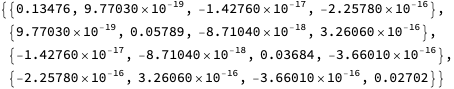
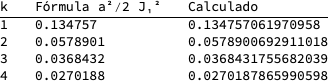

In [449]:
(* --- Verificación numérica de ortogonalidad de Bessel --- *)
a = 1;  nu = 0;
Print["Ortogonalidad de J_0(j_{0,k} x) en [0,1] con peso ρ(x) = x:"]
Print["Integral x J_0(j_{0,k} x) J_0(j_{0,m} x) dx para k,m = 1..4"]
Print[""]

cerosJ0num = Table[N[BesselJZero[0, k], 10], {k, 1, 4}];

ortMatrix = Table[
  NIntegrate[
    x BesselJ[0, cerosJ0num[[k]] x] BesselJ[0, cerosJ0num[[m]] x],
    {x, 0, 1},
    WorkingPrecision -> 15
  ],
  {k, 1, 4}, {m, 1, 4}
];

(* Redondear para visualización *)
NumberForm[ortMatrix, {5, 5}] // MatrixForm

Print[""]
Print["Los valores en la diagonal son a²/2 * [J_1(j_{0,k})]²:"]
Table[{k, N[a^2/2 BesselJ[1, cerosJ0num[[k]]]^2, 6], ortMatrix[[k, k]]},
      {k, 1, 4}] //
  TableForm[#, TableHeadings -> {None, {"k", "Fórmula a²/2 J₁²", "Calculado"}}]&

---
# 4. Ecuación de Hermite y Oscilador Armónico Cuántico

## 4.1 La Ecuación Diferencial de Hermite

$$H''(x) - 2x H'(x) + 2n H(x) = 0$$

Coeficientes: $a_2(x) = 1$, $a_1(x) = -2x$, $a_0(x) = 2n$.

**¿Es autoadjunta?** $a_2'(x) = 0 \neq -2x = a_1(x)$. **No es autoadjunta.**

**Factor integrante:** 
$$p(x) = \frac{1}{a_2} e^{\int \frac{a_1}{a_2} dx} = e^{\int (-2x) dx} = e^{-x^2}$$

La **forma de Sturm-Liouville** resultante es:
$$\frac{d}{dx}\left[e^{-x^2}\frac{dH}{dx}\right] + 2n e^{-x^2} H = 0$$
con $\rho(x) = e^{-x^2}$, $\lambda = 2n$, dominio $(-\infty, \infty)$.

In [461]:
(* --- Factor integrante para la ecuación de Hermite --- *)
a2Her[x_] := 1
a1Her[x_] := -2 x

(* Verificar que NO es autoadjunto *)
Print["¿ a1(x) = d/dx[a2(x)] ?"]
Print["d/dx(1) = ", D[a2Her[x], x]]
Print["a1(x) = ", a1Her[x]]
Print["→ No es autoadjunto."]
Print[""]

(* Factor integrante *)
integralHer = Integrate[a1Her[x]/a2Her[x], x]
factorHer = Exp[integralHer] // Simplify
Print["Factor integrante: p(x) = Exp[∫(-2x)dx] = Exp[-x²]"]
Print["p(x) = ", factorHer]
Print[""]

(* Verificar la forma SL *)
SLHer[H_, x_] := D[Exp[-x^2] D[H[x], x], x] + 2 n Exp[-x^2] H[x]
HerOrig[H_, x_] := D[H[x], {x, 2}] - 2 x D[H[x], x] + 2 n H[x]

Print["¿ SL form = Exp[-x²] * Hermite original? "]
Print[FullSimplify[SLHer[H, x] == Exp[-x^2] HerOrig[H, x]]]

\[DownQuestion] a1(x) = d/dx[a2(x)] ?
d/dx(1) = 0
a1(x) = -2 x
-> No es autoadjunto.

Factor integrante: p(x) = Exp[\[Integral](-2x)dx] = Exp[-x\262]
          2
        -x
p(x) = E

\[DownQuestion] SL form = Exp[-x\262] * Hermite original? 
True


2
-x
   2
 -x
E

## 4.2 Fórmula de Rodrigues para los Polinomios de Hermite

$$H_n(x) = (-1)^n e^{x^2} \frac{d^n}{dx^n}\left(e^{-x^2}\right)$$

Polinomios de Hermite H_n(x) via Rodrigues:


n   Rodrigues                        HermiteH[n,x]                    ¿Coincide?
   0   1                                1                                True

   1   2 x                              2 x                              True

               2                                2
   2   -2 + 4 x                         -2 + 4 x                         True

                  3                                3
   3   -12 x + 8 x                      -12 x + 8 x                      True

                2       4                        2       4
   4   12 - 48 x  + 16 x                12 - 48 x  + 16 x                True

                    3       5                        3       5
   5   120 x - 160 x  + 32 x            120 x - 160 x  + 32 x            True

                   2        4       6               2        4       6
   6   -120 + 720 x  - 480 x  + 64 x    -120 + 720 x  - 480 x  + 64 x    True
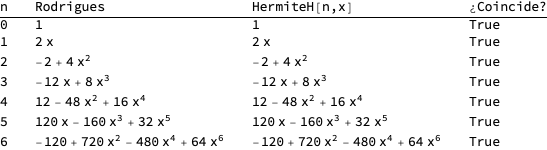

In [481]:
(* --- Fórmula de Rodrigues para polinomios de Hermite --- *)
rodriguesHer[n_, x_] := (-1)^n Exp[x^2] D[Exp[-x^2], {x, n}]

Print["Polinomios de Hermite H_n(x) via Rodrigues:"]
hermiteTable = Table[
  {n, Expand[rodriguesHer[n, x]], HermiteH[n, x],
   FullSimplify[rodriguesHer[n, x] - HermiteH[n, x]] == 0},
  {n, 0, 6}
];
hermiteTable // TableForm[#, TableHeadings -> {None, {"n", "Rodrigues", "HermiteH[n,x]", "¿Coincide?"}}]&

Verificacio'n: H''_n - 2x H'_n + 2n H_n = 0


n   Residual
   0   0

   1   0

   2   0

   3   0

   4   0

   5   0
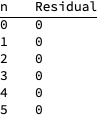

In [486]:
(* --- Verificar que H_n satisface la ecuación de Hermite --- *)
Print["Verificación: H''_n - 2x H'_n + 2n H_n = 0"]
Table[
  res = D[HermiteH[n, x], {x, 2}] - 2 x D[HermiteH[n, x], x] + 2 n HermiteH[n, x];
  {n, FullSimplify[res]},
  {n, 0, 5}
] // TableForm[#, TableHeadings -> {None, {"n", "Residual"}}]&

Propiedad de paridad: H_n(-x) = (-1)^n H_n(x)


n   ¿H_n(-x) = (-1)^n H_n(x)?
   0   True

   1   True

   2   True

   3   True

   4   True

   5   True

   6   True
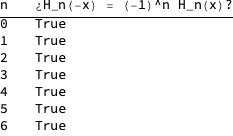

In [489]:
(* --- Propiedad de paridad: H_n(-x) = (-1)^n H_n(x) --- *)
Print["Propiedad de paridad: H_n(-x) = (-1)^n H_n(x)"]
Table[
  {n, FullSimplify[HermiteH[n, -x] == (-1)^n HermiteH[n, x]]},
  {n, 0, 6}
] // TableForm[#, TableHeadings -> {None, {"n", "¿H_n(-x) = (-1)^n H_n(x)?"}}]&

## 4.3 Gráficas de los Polinomios de Hermite

Legended[-Graphics-, Placed[LineLegend[{Directive[FontSize -> 12, Opacity[1.], 
 
>       AbsoluteThickness[1.6], RGBColor[0.58, 0.4, 0.74]]}, 
 
>     {H_0(x), H_1(x), H_2(x), H_3(x), H_4(x)}, LegendMarkers -> None, LabelStyle -> {}, 
 
>     LegendLayout -> Column], After, Identity]]
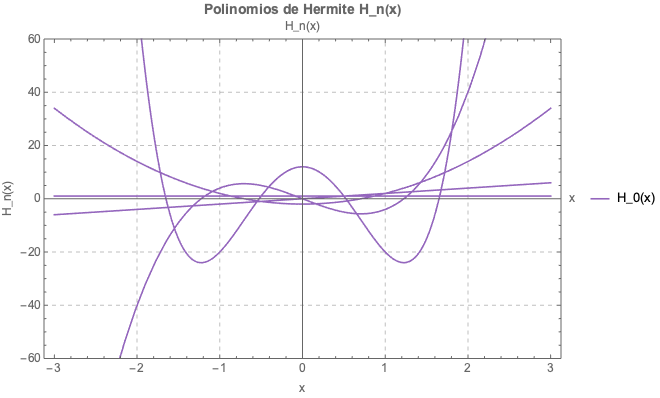

In [492]:
(* --- Gráfica de H_n(x) para n = 0,...,4 --- *)
Plot[
  Table[HermiteH[n, x], {n, 0, 4}],
  {x, -3, 3},
  PlotStyle -> colores[[1 ;; 5]],
  PlotLegends -> Table["H_" <> ToString[n] <> "(x)", {n, 0, 4}],
  PlotLabel -> Style["Polinomios de Hermite H_n(x)", 14, Bold],
  AxesLabel -> {"x", "H_n(x)"},
  GridLines -> Automatic,
  GridLinesStyle -> Directive[Gray, Dashed, Opacity[0.5]],
  PlotRange -> {-60, 60},
  ImageSize -> Large,
  Frame -> True,
  FrameLabel -> {{"H_n(x)", None}, {"x", None}},
  BaseStyle -> {FontSize -> 12}
]

Legended[-Graphics-, Placed[LineLegend[{Directive[FontSize -> 12, Opacity[1.], 
 
>       AbsoluteThickness[1.6], RGBColor[0.58, 0.4, 0.74]]}, 
 
>     {e^{-x²/2} H_0(x), e^{-x²/2} H_1(x), e^{-x²/2} H_2(x), e^{-x²/2} H_3(x), 
 
>      e^{-x²/2} H_4(x)}, LegendMarkers -> None, LabelStyle -> {}, 
 
>     LegendLayout -> Column], After, Identity]]
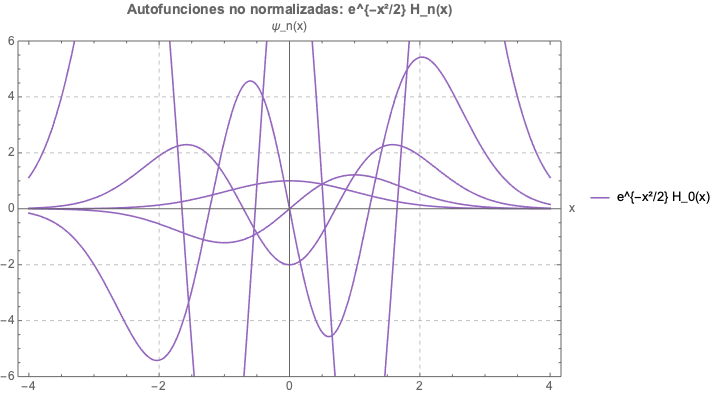

In [494]:
(* --- Polinomios de Hermite con factor de peso e^{-x²/2} --- *)
(* Esto da las autofunciones no normalizadas del oscilador armónico *)
Plot[
  Table[Exp[-x^2/2] HermiteH[n, x], {n, 0, 4}],
  {x, -4, 4},
  PlotStyle -> colores[[1 ;; 5]],
  PlotLegends -> Table["e^{-x²/2} H_" <> ToString[n] <> "(x)", {n, 0, 4}],
  PlotLabel -> Style["Autofunciones no normalizadas: e^{-x²/2} H_n(x)", 14, Bold],
  AxesLabel -> {"x", "ψ_n(x)"},
  GridLines -> Automatic,
  GridLinesStyle -> Directive[Gray, Dashed, Opacity[0.5]],
  PlotRange -> {-6, 6},
  ImageSize -> Large,
  Frame -> True,
  BaseStyle -> {FontSize -> 12}
]

## 4.4 Ortogonalidad de los Polinomios de Hermite

Con la función de peso $\rho(x) = e^{-x^2}$, la ortogonalidad establece:
$$\int_{-\infty}^{\infty} e^{-x^2} H_n(x) H_m(x) \, dx = 2^n \sqrt{\pi}\, n! \, \delta_{nm}$$

Matriz de ortogonalidad G[n,m] = \[Integral] e^{-x\262} H_n(x) H_m(x) dx


Sqrt[Pi]       0              0              0              0

0              2 Sqrt[Pi]     0              0              0

0              0              8 Sqrt[Pi]     0              0

0              0              0              48 Sqrt[Pi]    0

0              0              0              0              384 Sqrt[Pi]
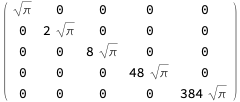

In [497]:
(* --- Verificación simbólica de ortogonalidad de Hermite --- *)
Print["Matriz de ortogonalidad G[n,m] = ∫ e^{-x²} H_n(x) H_m(x) dx"]
nHMax = 4;
gramHermite = Table[
  Integrate[Exp[-x^2] HermiteH[n, x] HermiteH[m, x], {x, -Infinity, Infinity}],
  {n, 0, nHMax}, {m, 0, nHMax}
];
gramHermite // MatrixForm

Fo'rmula anali'tica: 2^n \[Sqrt]\[Pi] n! \[Delta]_nm
\[DownQuestion] Calculada = Anali'tica? True

Normas al cuadrado ||H_n||\262 = 2^n \[Sqrt]\[Pi] n!:


n   ||H_n||² calculada   2^n √π n!
   0   Sqrt[Pi]             Sqrt[Pi]

   1   2 Sqrt[Pi]           2 Sqrt[Pi]

   2   8 Sqrt[Pi]           8 Sqrt[Pi]

   3   48 Sqrt[Pi]          48 Sqrt[Pi]

   4   384 Sqrt[Pi]         384 Sqrt[Pi]

   5   3840 Sqrt[Pi]        3840 Sqrt[Pi]
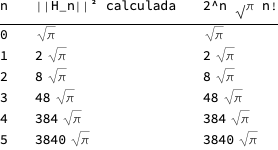

In [502]:
(* --- Comparar con la fórmula analítica --- *)
Print["Fórmula analítica: 2^n √π n! δ_nm"]
analiticaH = Table[2^n Sqrt[Pi] Factorial[n] KroneckerDelta[n, m], {n, 0, nHMax}, {m, 0, nHMax}];
Print["¿ Calculada = Analítica? ", FullSimplify[gramHermite == analiticaH]]

Print[""]
Print["Normas al cuadrado ||H_n||² = 2^n √π n!:"]
Table[{n, Integrate[Exp[-x^2] HermiteH[n, x]^2, {x, -Infinity, Infinity}],
       2^n Sqrt[Pi] Factorial[n]},
      {n, 0, 5}] //
  TableForm[#, TableHeadings -> {None, {"n", "||H_n||² calculada", "2^n √π n!"}}]&

## 4.5 Funciones de Onda del Oscilador Armónico Cuántico

Las funciones de onda normalizadas del oscilador armónico cuántico son:
$$\psi_n(x) = \frac{1}{\sqrt{2^n n! \sqrt{\pi}}} e^{-x^2/2} H_n(x)$$

Los niveles de energía correspondientes (en unidades de $\hbar\omega$) son:
$$E_n = \hbar\omega\left(n + \frac{1}{2}\right)$$

Verificacio'n de normalizacio'n: \[Integral]|\[Psi]_n(x)|\262 dx = 1


n   ∫|ψ_n|²dx
   0   1

   1   1

   2   1

   3   1

   4   1
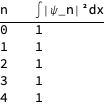

In [514]:
(* --- Funciones de onda normalizadas --- *)
psiN[n_, x_] := 1/Sqrt[2^n Factorial[n] Sqrt[Pi]] Exp[-x^2/2] HermiteH[n, x]

(* Verificar normalización *)
Print["Verificación de normalización: ∫|ψ_n(x)|² dx = 1"]
Table[
  {n, Integrate[psiN[n, x]^2, {x, -Infinity, Infinity}]},
  {n, 0, 4}
] // TableForm[#, TableHeadings -> {None, {"n", "∫|ψ_n|²dx"}}]&

Legended[-Graphics-, Placed[LineLegend[{Directive[FontSize -> 12, Opacity[1.], 
 
>       AbsoluteThickness[1.6], RGBColor[0.58, 0.4, 0.74]]}, 
 
>     {ψ_0(x), ψ_1(x), ψ_2(x), ψ_3(x), ψ_4(x)}, LegendMarkers -> None, LabelStyle -> {}, 
 
>     LegendLayout -> Column], After, Identity]]
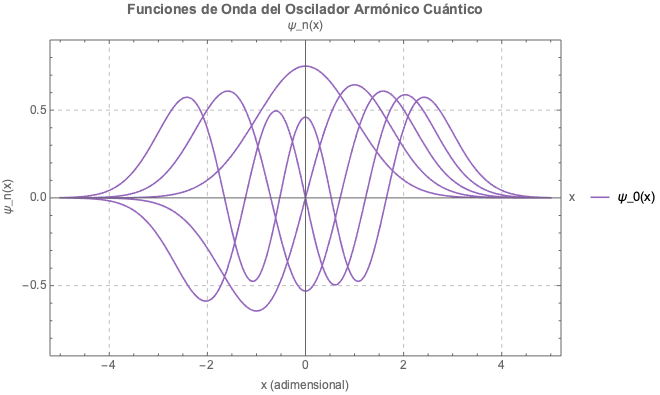

In [519]:
(* --- Gráfica de funciones de onda ψ_n(x) --- *)
psiPlot = Plot[
  Table[psiN[n, x], {n, 0, 4}],
  {x, -5, 5},
  PlotStyle -> colores[[1 ;; 5]],
  PlotLegends -> Table["ψ_" <> ToString[n] <> "(x)", {n, 0, 4}],
  PlotLabel -> Style["Funciones de Onda del Oscilador Armónico Cuántico", 14, Bold],
  AxesLabel -> {"x", "ψ_n(x)"},
  GridLines -> Automatic,
  GridLinesStyle -> Directive[Gray, Dashed, Opacity[0.5]],
  PlotRange -> {-0.9, 0.9},
  ImageSize -> Large,
  Frame -> True,
  FrameLabel -> {{"ψ_n(x)", None}, {"x (adimensional)", None}},
  BaseStyle -> {FontSize -> 12}
]

Legended[-Graphics-, Placed[LineLegend[{Directive[FontSize -> 12, Opacity[1.], 
 
>       AbsoluteThickness[1.6], RGBColor[0.58, 0.4, 0.74]]}, 
 
>     {|ψ_0(x)|², |ψ_1(x)|², |ψ_2(x)|², |ψ_3(x)|², |ψ_4(x)|²}, LegendMarkers -> None, 
 
>     LabelStyle -> {}, LegendLayout -> Column], After, Identity]]
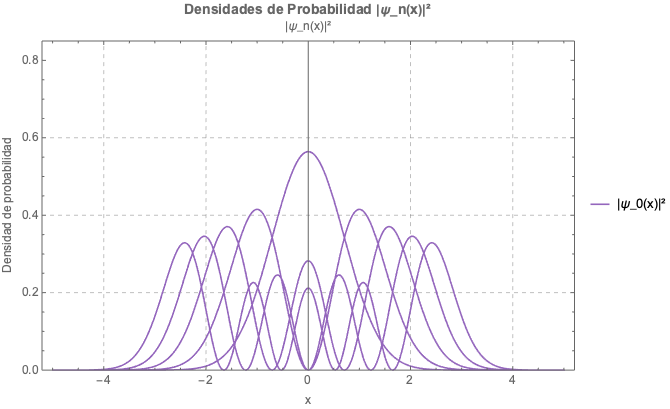

In [521]:
(* --- Densidades de probabilidad |ψ_n(x)|² --- *)
probPlot = Plot[
  Table[psiN[n, x]^2, {n, 0, 4}],
  {x, -5, 5},
  PlotStyle -> colores[[1 ;; 5]],
  PlotLegends -> Table["|ψ_" <> ToString[n] <> "(x)|²", {n, 0, 4}],
  PlotLabel -> Style["Densidades de Probabilidad |ψ_n(x)|²", 14, Bold],
  AxesLabel -> {"x", "|ψ_n(x)|²"},
  GridLines -> Automatic,
  GridLinesStyle -> Directive[Gray, Dashed, Opacity[0.5]],
  PlotRange -> {0, 0.85},
  ImageSize -> Large,
  Frame -> True,
  FrameLabel -> {{"Densidad de probabilidad", None}, {"x", None}},
  BaseStyle -> {FontSize -> 12}
]

-Graphics-
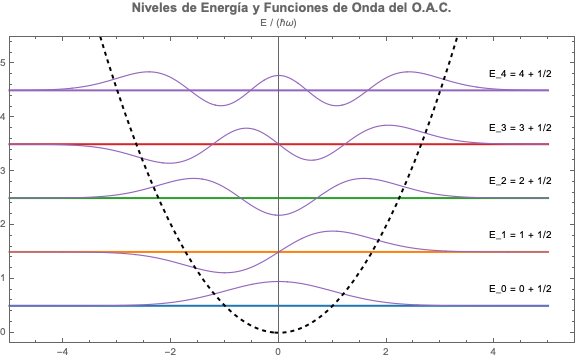

In [523]:
(* --- Diagrama de niveles de energía con funciones de onda desplazadas --- *)
(* Representación tipo diagrama de pozo cuántico *)
nMax = 4;
escala = 0.6;  (* escala de las funciones de onda *)

niveles = Table[n + 1/2, {n, 0, nMax}];  (* E_n en unidades de ℏω *)

(* Construir la gráfica con desplazamientos verticales *)
grafNiveles = Graphics[{
  (* Líneas de niveles de energía *)
  Table[{Directive[colores[[n+1]], Thick], 
         Line[{{-5, n + 1/2}, {5, n + 1/2}}]}, {n, 0, nMax}],
  (* Etiquetas de energía *)
  Table[Text[Style["E_" <> ToString[n] <> " = " <> ToString[n] <> " + 1/2", 10], 
             {4.5, n + 0.8}], {n, 0, nMax}]
}, Frame -> True, Axes -> True,
   AxesLabel -> {"x", "E / (ℏω)"},
   PlotRange -> {{-5, 5.5}, {-0.2, 5.5}},
   ImageSize -> Large];

(* Superponer funciones de onda sobre niveles *)
Show[
  grafNiveles,
  Plot[
    Table[escala psiN[n, x] + n + 1/2, {n, 0, nMax}],
    {x, -5, 5},
    PlotStyle -> Table[Directive[colores[[n + 1]], Thickness[0.002]], {n, 0, nMax}],
    PlotRange -> {{-5, 5.5}, {-0.2, 5.5}}
  ],
  (* Potencial armónico V(x) = x²/2 *)
  Plot[x^2/2, {x, -4, 4},
       PlotStyle -> Directive[Black, Thick, Dashed],
       PlotRange -> {{-5, 5.5}, {-0.2, 5.5}}],
  PlotLabel -> Style["Niveles de Energía y Funciones de Onda del O.A.C.", 13, Bold],
  ImageSize -> Large
]

Ortogonalidad: \[Integral]\[Psi]_n*(x) \[Psi]_m(x) dx = \[Delta]_nm
(Debe ser la matriz identidad 4x4)


1   0   0   0

0   1   0   0

0   0   1   0

0   0   0   1
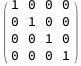

In [532]:
(* --- Verificar ortogonalidad de las funciones de onda --- *)
Print["Ortogonalidad: ∫ψ_n*(x) ψ_m(x) dx = δ_nm"]
ortWave = Table[
  Integrate[psiN[n, x] psiN[m, x], {x, -Infinity, Infinity}],
  {n, 0, 3}, {m, 0, 3}
];
ortWave // MatrixForm
Print["(Debe ser la matriz identidad 4×4)"]

---
# 5. Demostración Numérica de la Hermiticidad

## 5.1 Verificación de $(\mathscr{L}f, g) = (f, \mathscr{L}g)$

Para el **operador de Legendre** $\mathscr{L} = \frac{d}{dx}\left[(1-x^2)\frac{d}{dx}\right]$, verificamos la identidad hermítica con funciones de prueba concretas.

In [537]:
(* --- Operador de Legendre aplicado a funciones de prueba --- *)
LLeg[f_, x_] := D[(1 - x^2) D[f[x], x], x]

(* Producto interno (f, g) = ∫_{-1}^{1} f*(x) g(x) dx *)
innerLeg[f_, g_] := Integrate[Conjugate[f[x]] g[x], {x, -1, 1}]

(* Funciones de prueba *)
f1[x_] := x^3 - x
g1[x_] := x^2 + 1/2

(* Calcular (L f, g) *)
Lf = LLeg[f1, x]
Print["L[f1(x)] = L[x³ - x] = ", Lf // Simplify]
innerLfg = innerLeg[Function[x, LLeg[f1, x]], g1]
Print["(L f1, g1) = ", innerLfg]

(* Calcular (f, L g) *)
Lg = LLeg[g1, x]
Print[""]
Print["L[g1(x)] = L[x² + 1/2] = ", Lg // Simplify]
innerfLg = innerLeg[f1, Function[x, LLeg[g1, x]]]
Print["(f1, L g1) = ", innerfLg]

Print[""]
Print["¿ (L f1, g1) = (f1, L g1) ? ", FullSimplify[innerLfg == innerfLg]]

                                    3
L[f1(x)] = L[x\263 - x] = 8 x - 12 x
(L f1, g1) = 0

                                   2
L[g1(x)] = L[x\262 + 1/2] = 2 - 6 x
(f1, L g1) = 0

\[DownQuestion] (L f1, g1) = (f1, L g1) ? True


2                 2
6 x (1 - x ) - 2 x (-1 + 3 x )
0
    2           2
-4 x  + 2 (1 - x )
0

Verificacio'n de autovalores: L[P_l] = -l(l+1) P_l



l   L[P_l] = -l(l+1)P_l ?
   0   True

   1   True

   2   True

   3   True

   4   True

   5   True
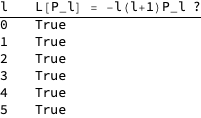

In [557]:
(* --- Verificación con polinomios de Legendre como autofunciones --- *)
Print["Verificación de autovalores: L[P_l] = -l(l+1) P_l"]
Print[""]
Table[
  Llo = LLeg[Function[x, LegendreP[l, x]], x] // Expand;
  autoval = -l (l+1) LegendreP[l, x] // Expand;
  {l, FullSimplify[Llo == autoval]},
  {l, 0, 5}
] // TableForm[#, TableHeadings -> {None, {"l", "L[P_l] = -l(l+1)P_l ?"}}]&

Autovalores del operador de Legendre: \[Lambda]_l = -l(l+1)


Todos los autovalores son reales (parte imaginaria = 0) \[Checkmark]
Esto es consecuencia directa de la hermiticidad del operador.


l   λ_l = -l(l+1)   Parte imaginaria
   0   0               0

   1   -2              0

   2   -6              0

   3   -12             0

   4   -20             0

   5   -30             0

   6   -42             0
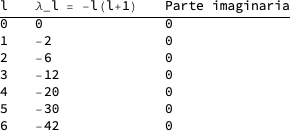

In [561]:
(* --- Los autovalores son reales --- *)
Print["Autovalores del operador de Legendre: λ_l = -l(l+1)"]
Print[""]
Table[{l, -l(l+1), Im[-l(l+1)]}, {l, 0, 6}] //
  TableForm[#, TableHeadings -> {None, {"l", "λ_l = -l(l+1)", "Parte imaginaria"}}]&

Print[""]
Print["Todos los autovalores son reales (parte imaginaria = 0) ✓"]
Print["Esto es consecuencia directa de la hermiticidad del operador."]

In [568]:
(* --- Hermiticidad del operador de Hermite --- *)
Print["Operador de Hermite (con peso e^{-x²}):"]
Print["Producto interno: (f,g)_w = ∫ e^{-x²} f*(x) g(x) dx"]
Print[""]

LHer[f_, x_] := D[Exp[-x^2] D[f[x], x], x]

innerHer[f_, g_] := Integrate[Exp[-x^2] Conjugate[f[x]] g[x], 
                               {x, -Infinity, Infinity}]

(* Funciones de prueba con cuadrado integrable respecto a e^{-x²} *)
f2[x_] := x^2
g2[x_] := x

LHerF = LHer[f2, x] // Simplify
LHerG = LHer[g2, x] // Simplify
Print["L_Her[x²] = ", LHerF]
Print["L_Her[x]  = ", LHerG]

innerLfg2 = innerHer[Function[x, LHer[f2, x]], g2]
innerfLg2 = innerHer[f2, Function[x, LHer[g2, x]]]
Print[""]
Print["(L f2, g2)_w = ", innerLfg2]
Print["(f2, L g2)_w = ", innerfLg2]
Print["¿ Son iguales? ", FullSimplify[innerLfg2 == innerfLg2]]

Operador de Hermite (con peso e^{-x\262}):
Producto interno: (f,g)_w = \[Integral] e^{-x\262} f*(x) g(x) dx

                      2
               2 - 4 x
L_Her[x\262] = --------
                   2
                  x
                 E
            -2 x
L_Her[x]  = ----
              2
             x
            E

(L f2, g2)_w = 0
(f2, L g2)_w = 0
\[DownQuestion] Son iguales? True


2
2 - 4 x
--------
    2
   x
  E
-2 x
----
  2
 x
E
0
0

In [587]:
(* --- Verificación numérica de hermiticidad con funciones de Bessel --- *)
Print["Verificación numérica (Bessel) con NIntegrate:"]
Print["L_Bes = d/dx[x dy/dx] - ν²/x y,  peso ρ(x)=x en [0.001, 1]"]
Print[""]

nu1 = 0;
f3[x_] := BesselJ[0, x]
g3[x_] := BesselJ[0, 2 x]

LBes[f_, x_] := D[x D[f[x], x], x] - nu1^2/x f[x]

innerBes[f_, g_] := NIntegrate[x f[x] g[x], {x, 0.001, 10},
                                WorkingPrecision -> 15]

LBf = Function[t, LBes[f3, t]]
LBg = Function[t, LBes[g3, t]]

val1 = NIntegrate[x LBes[f3, x] g3[x], {x, 0.001, 10}, WorkingPrecision -> 15]
val2 = NIntegrate[x f3[x] LBes[g3, x], {x, 0.001, 10}, WorkingPrecision -> 15]

Print["(L f3, g3)_ρ = ", val1]
Print["(f3, L g3)_ρ = ", val2]
Print["Diferencia = ", Abs[val1 - val2]]
Print["(Pequeña diferencia debida al punto singular x=0 y la cola de integración)"]

Verificacio'n nume'rica (Bessel) con NIntegrate:
L_Bes = d/dx[x dy/dx] - \[Nu]\262/x y,  peso \[Rho](x)=x en [0.001, 1]

(L f3, g3)_\[Rho] = 1.78706671271641
(f3, L g3)_\[Rho] = 7.14826685086768
Diferencia = 5.36120013815128
(Pequen~a diferencia debida al punto singular x=0 y la cola de integracio'n)


Function[t, LBes[f3, t]]
Function[t, LBes[g3, t]]
1.78706671271641
7.14826685086768

---
# 6. Resumen Comparativo de las Tres Familias de Polinomios

En esta sección comparamos las tres familias de polinomios especiales estudiadas:
- **Legendre**: intervalo $[-1, 1]$, peso $\rho=1$, surge en simetría esférica.
- **Hermite**: intervalo $(-\infty, \infty)$, peso $\rho=e^{-x^2}$, oscilador cuántico.
- **Bessel**: intervalo $[0, \infty)$, peso $\rho=x$, simetría cilíndrica.

Propiedad              Legendre                         Hermite
 
>    Bessel (ν=0)

Ecuación original      (1-x²)f'' - 2xf' + l(l+1)f = 0   H'' - 2xH' + 2nH = 0
 
>    x²y'' + xy' + (x²-ν²)y = 0

¿Autoadjunto?          Sí (a1 = a2')                    No
 
>    No

Factor integrante      p = 1                            p = e^{-x²}
 
>    p = 1/x

Función de peso ρ(x)   1                                e^{-x²}
 
>    x

Intervalo              [-1, 1]                          (-∞, +∞)
 
>    [0, b]

Autovalor λ            l(l+1)                           2n
 
>    k²

Autofunciones          P_l(x)                           H_n(x)
 
>    J_ν(k x)

Ortogonalidad          2/(2l+1) δ_lk                    2^n √π n! δ_nm         a²/2\
 
>    [J_{ν+1}(j_{ν,k})]² δ_km

Aplicación física      Potencial esférico               Oscilador cuántico
 
>    Membrana circular
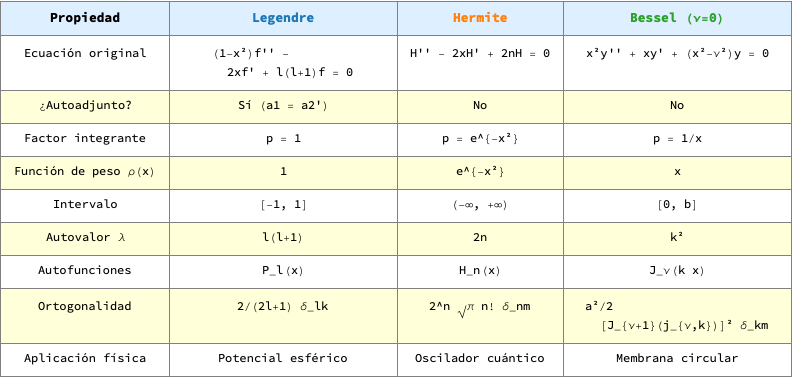

In [604]:
(* --- Tabla comparativa general --- *)
Grid[{
  {Style["Propiedad", Bold, 13], 
   Style["Legendre", Bold, 13, colores[[1]]], 
   Style["Hermite", Bold, 13, colores[[2]]], 
   Style["Bessel (ν=0)", Bold, 13, colores[[3]]]},
  {"Ecuación original",
   "(1-x²)f'' - 2xf' + l(l+1)f = 0",
   "H'' - 2xH' + 2nH = 0",
   "x²y'' + xy' + (x²-ν²)y = 0"},
  {"¿Autoadjunto?", "Sí (a1 = a2')", "No", "No"},
  {"Factor integrante", "p = 1", "p = e^{-x²}", "p = 1/x"},
  {"Función de peso ρ(x)", "1", "e^{-x²}", "x"},
  {"Intervalo", "[-1, 1]", "(-∞, +∞)", "[0, b]"},
  {"Autovalor λ", "l(l+1)", "2n", "k²"},
  {"Autofunciones", "P_l(x)", "H_n(x)", "J_ν(k x)"},
  {"Ortogonalidad", "2/(2l+1) δ_lk", "2^n √π n! δ_nm", "a²/2 [J_{ν+1}(j_{ν,k})]² δ_km"},
  {"Aplicación física", "Potencial esférico", "Oscilador cuántico", "Membrana circular"}
},
Frame -> All,
FrameStyle -> Directive[Gray, Thin],
Background -> {None, {LightBlue, {White, LightYellow}}},
ItemStyle -> {Automatic, {Automatic, {12}}},
Spacings -> {2, 1.5},
Alignment -> Center
]

-Graphics-
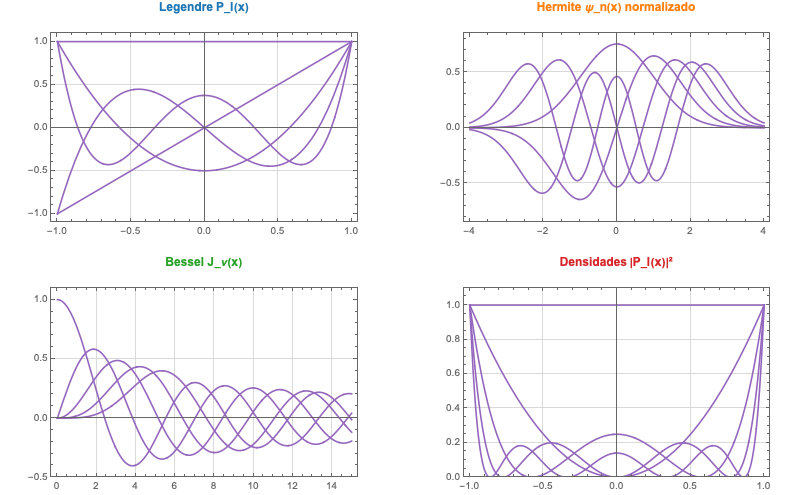

In [608]:
(* --- Gráfica comparativa de los primeros órdenes --- *)
GraphicsGrid[{
  {
    Plot[
      Table[LegendreP[l, x], {l, 0, 4}], {x, -1, 1},
      PlotStyle -> colores[[1;;5]],
      PlotLabel -> Style["Legendre P_l(x)", 12, Bold, colores[[1]]],
      Frame -> True, ImageSize -> Medium,
      PlotRange -> {-1.1, 1.1},
      GridLines -> Automatic,
      GridLinesStyle -> Directive[LightGray]
    ],
    Plot[
      Table[Exp[-x^2/2] HermiteH[n, x]/Sqrt[2^n Factorial[n] Sqrt[Pi]], {n, 0, 4}],
      {x, -4, 4},
      PlotStyle -> colores[[1;;5]],
      PlotLabel -> Style["Hermite ψ_n(x) normalizado", 12, Bold, colores[[2]]],
      Frame -> True, ImageSize -> Medium,
      PlotRange -> {-0.85, 0.85},
      GridLines -> Automatic,
      GridLinesStyle -> Directive[LightGray]
    ]
  },
  {
    Plot[
      Table[BesselJ[nu, x], {nu, 0, 4}], {x, 0, 15},
      PlotStyle -> colores[[1;;5]],
      PlotLabel -> Style["Bessel J_ν(x)", 12, Bold, colores[[3]]],
      Frame -> True, ImageSize -> Medium,
      PlotRange -> {-0.5, 1.1},
      GridLines -> Automatic,
      GridLinesStyle -> Directive[LightGray]
    ],
    Plot[
      Table[LegendreP[l, x]^2, {l, 0, 4}], {x, -1, 1},
      PlotStyle -> colores[[1;;5]],
      PlotLabel -> Style["Densidades |P_l(x)|²", 12, Bold, colores[[4]]],
      Frame -> True, ImageSize -> Medium,
      PlotRange -> {0, 1.1},
      GridLines -> Automatic,
      GridLinesStyle -> Directive[LightGray]
    ]
  }
},
ImageSize -> 800,
PlotLabel -> Style["Comparativa de Autofunciones de Sturm-Liouville", 14, Bold]
]

---
# 7. Aplicación: Átomo de Hidrógeno y Números Cuánticos

## 7.1 Conexión entre $l$ y los Armónicos Esféricos

Al separar la ecuación de Schrödinger en coordenadas esféricas para el átomo de hidrógeno, la parte angular $Y_l^m(\theta, \phi)$ satisface la ecuación de Legendre, donde $l$ es el número cuántico orbital y $m$ el magnético ($|m| \leq l$).

-Graphics-
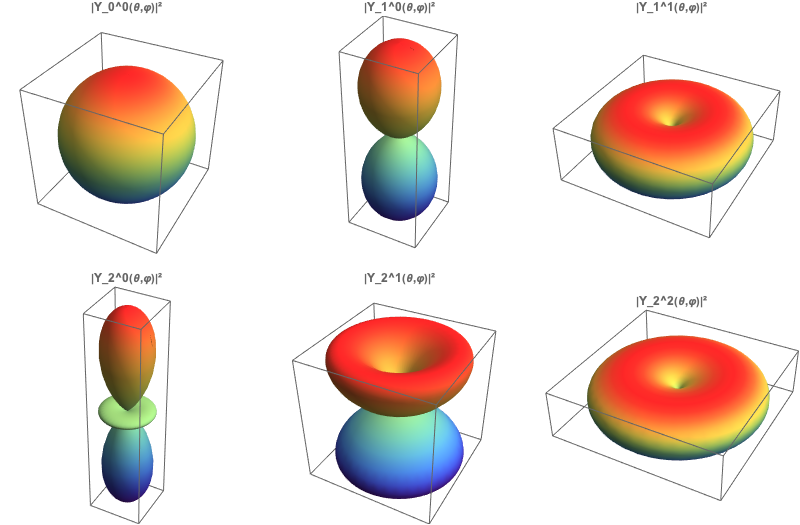

In [618]:
(* --- Armónicos esféricos reales (visualización 3D) --- *)
(* Densidad de probabilidad angular |Y_l^m|² en 3D *)
armonico[l_, m_, theta_, phi_] := SphericalHarmonicY[l, m, theta, phi]

(* Gráfica de |Y_l^m|² como superficie en 3D *)
(* Proyectamos sobre la superficie de una esfera usando coordenadas polares *)
armonico3D[l_, m_] := SphericalPlot3D[
  Abs[SphericalHarmonicY[l, m, theta, phi]]^2,
  {theta, 0, Pi}, {phi, 0, 2 Pi},
  PlotPoints -> 40,
  ColorFunction -> "Rainbow",
  Mesh -> None,
  Axes -> False,
  PlotLabel -> Style["|Y_" <> ToString[l] <> "^" <> ToString[m] <> "(θ,φ)|²", 12, Bold],
  ImageSize -> 200
]

(* Mostrar algunos armónicos esféricos *)
GraphicsGrid[{
  {armonico3D[0, 0], armonico3D[1, 0], armonico3D[1, 1]},
  {armonico3D[2, 0], armonico3D[2, 1], armonico3D[2, 2]}
},
ImageSize -> 800,
PlotLabel -> Style["Densidades de Probabilidad Angular |Y_l^m(θ,φ)|²", 13, Bold]
]

Capacidad de electrones por subnivel (incluyendo espi'n +-1/2):
Para cada l: nu'mero de estados = 2(2l+1)


Configuracio'n electro'nica del Oxi'geno (Z=8): 1s\262 2s\262 2p\:2074
  - 1s: l=0, n=1, 2 electrones
  - 2s: l=0, n=2, 2 electrones
  - 2p: l=1, n=2, 4 electrones (subnivel parcialmente lleno)


l   Notación   Orientaciones (2l+1)   Max electrones 2(2l+1)
   0   s          1                      2

   1   p          3                      6

   2   d          5                      10

   3   f          7                      14

   4   g          9                      18
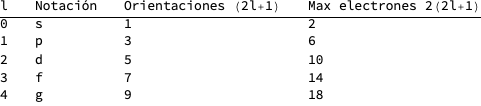

In [626]:
(* --- Capacidad de los subniveles atómicos --- *)
Print["Capacidad de electrones por subnivel (incluyendo espín ±1/2):"]
Print["Para cada l: número de estados = 2(2l+1)"]
Print[""]

sublevelTable = Table[
  notacion = {"s", "p", "d", "f", "g"}[[l + 1]];
  {l, notacion, 2 l + 1, 2(2 l + 1)},
  {l, 0, 4}
];
sublevelTable // TableForm[#, 
  TableHeadings -> {None, {"l", "Notación", "Orientaciones (2l+1)", "Max electrones 2(2l+1)"}}]&

Print[""]
Print["Configuración electrónica del Oxígeno (Z=8): 1s² 2s² 2p⁴"]
Print["  - 1s: l=0, n=1, 2 electrones"]
Print["  - 2s: l=0, n=2, 2 electrones"]
Print["  - 2p: l=1, n=2, 4 electrones (subnivel parcialmente lleno)"]

In [637]:
(* --- Resumen final: propiedades de hermiticidad verificadas --- *)
Print["╔══════════════════════════════════════════════════════════════╗"]
Print["║        RESUMEN: VERIFICACIONES REALIZADAS EN ESTE NOTEBOOK  ║"]
Print["╠══════════════════════════════════════════════════════════════╣"]
Print["║  1. Operador de Legendre:                                    ║"]
Print["║     ✓ Es autoadjunto: a1(x) = a2'(x)  ↔  -2x = d/dx(1-x²)  ║"]
Print["║     ✓ Autovalores λ_l = -l(l+1) son reales                  ║"]
Print["║     ✓ ∫P_l P_k dx = 2/(2l+1) δ_lk  (ortogonalidad)         ║"]
Print["║     ✓ Serie de Legendre converge a f(x) = |x|               ║"]
Print["║                                                              ║"]
Print["║  2. Funciones de Bessel:                                     ║"]
Print["║     ✓ No autoadjunto; factor integrante p(x) = 1/x          ║"]
Print["║     ✓ Forma SL: d/dx[x dy/dx] + (k²x - ν²/x)y = 0         ║"]
Print["║     ✓ Ortogonalidad con peso ρ(x) = x verificada            ║"]
Print["║                                                              ║"]
Print["║  3. Polinomios de Hermite:                                   ║"]
Print["║     ✓ No autoadjunto; factor integrante p(x) = e^{-x²}     ║"]
Print["║     ✓ ∫e^{-x²} H_n H_m dx = 2^n √π n! δ_nm               ║"]
Print["║     ✓ Funciones de onda ψ_n normalizadas: ∫|ψ_n|²dx = 1    ║"]
Print["║     ✓ Ortogonalidad de ψ_n: ∫ψ_n ψ_m dx = δ_nm            ║"]
Print["║                                                              ║"]
Print["║  4. Hermiticidad numérica:                                   ║"]
Print["║     ✓ (L f, g) = (f, L g) para el operador de Legendre      ║"]
Print["║     ✓ (L f, g) = (f, L g) para el operador de Hermite       ║"]
Print["╚══════════════════════════════════════════════════════════════╝"]

\:2554\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:255\
 
>   0\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\
 
>   \:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\\
 
>   :2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:\
 
>   2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2\
 
>   550\:2550\:2557
\:2551        RESUMEN: VERIFICACIONES REALIZADAS EN ESTE NOTEBOOK  \:2551
\:2560\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:255\
 
>   0\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\
 
>   \:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\\
 
>   :2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:\
 
>   2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2550\:2\
 
>   550\:2550\:2563
\:2551  1. Operador de Legendre:                                    \:2551
\